# Análise de vendas

Objetivo: 
Analisar o desempenho de vendas, por categorias de produtos, regiões,comportamento de clientes e metodos de pagamento.
Encontrando padrões para que a empresa possa melhorar suas estrategias de vendas.

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv("../data/sales_data.csv")


In [91]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


## Visão geral dos dados

O dataset possui 1000 registros de vendas, contendo informações uteis como tipo de produtos, metodos de pagamento, tipos de cliente, quantidade e valor total vendido por cada produto e regiões, com essas informações podemos realizar as analises descritas acima

In [92]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


O valor médio de vendas(Sales_Amount) é de $5019.26, onde seu maior valor é de $9989.04

In [93]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


# Realizando analise de vendas mensais

<Axes: title={'center': 'Faturamento mensal'}, xlabel='Month', ylabel='Faturamento mensal'>

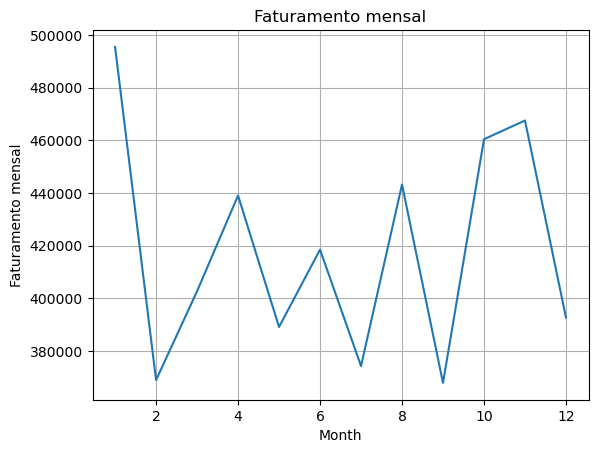

In [153]:
# Transformando Sale_date de objeto para datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

# Criação de uma coluna mes para realizar analise mensal
df['Month'] = df['Sale_Date'].dt.month

faturamento_mensal = df.groupby('Month')['Sales_Amount'].sum()

faturamento_mensal.plot(kind= 'line', grid=True, ylabel= 'Faturamento mensal', title='Faturamento mensal')

Podemos Ver menor indice de vendas no mes 2, e maior no mes 1 

# Faturamento total de vendas

In [94]:

total_vendido = df['Sales_Amount'].sum()
total_vendido

np.float64(5019265.2299999995)

Faturamento total das vendas é de $5019265.22

# Faturamento por região

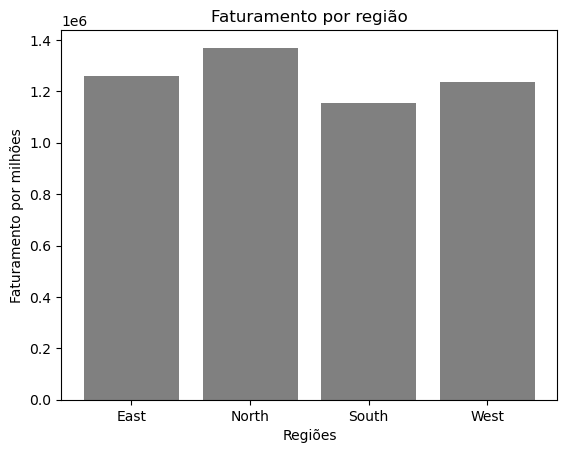

In [95]:

#Faturamento por regiao
faturamento_região = df.groupby('Region')['Sales_Amount'].sum()
plt.bar(faturamento_região.index, faturamento_região.values, color = 'gray')
plt.xlabel("Regiões")
plt.ylabel("Faturamento por milhões")
plt.title('Faturamento por região')
plt.show()

A região North representa o maior faturamento enquanto a região South o menor

O que torna interessante campanhas em regiões com baixo faturamento com promoções especificas apenas nelas

# Faturamento por categoria

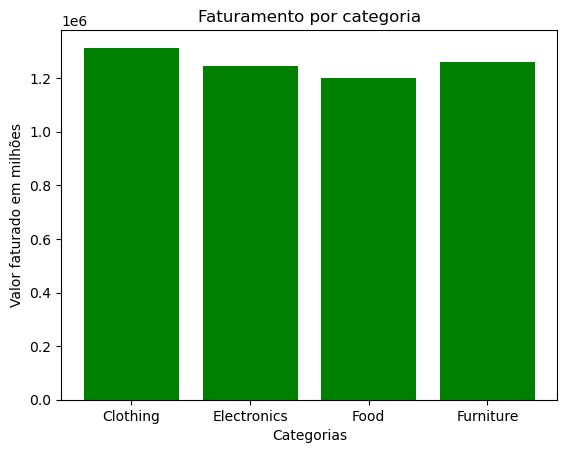

In [96]:
#Categoria de produto que mais vende em faturamento
faturamento_categoria = df.groupby('Product_Category')['Sales_Amount'].sum()

plt.bar(faturamento_categoria.index, faturamento_categoria.values, color = 'green')
plt.ylabel("Valor faturado em milhões")
plt.xlabel("Categorias")
plt.title("Faturamento por categoria")
plt.show()

Categoria que gerou mais faturamento foi a Clothing ja a que menos gerou a Food

# Quantidade vendida por categora

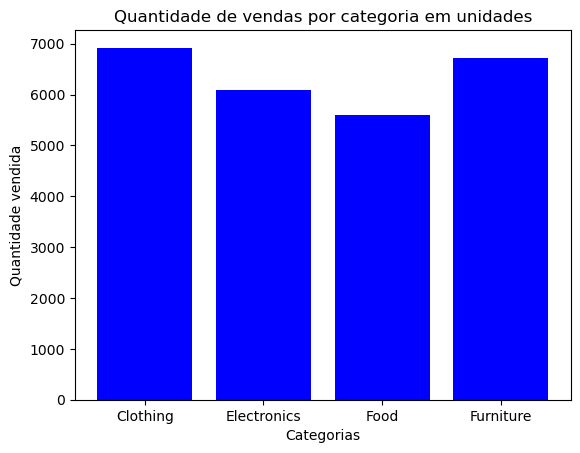

In [97]:
unidades_categoria = df.groupby('Product_Category')['Quantity_Sold'].sum()

plt.bar(unidades_categoria.index, unidades_categoria.values, color = 'blue')
plt.xlabel("Categorias")
plt.ylabel("Quantidade vendida")
plt.title("Quantidade de vendas por categoria em unidades")
plt.show()

Em relação ao faturamento seguem o mesmo padrão, mais vendida como Clothing e menos vendida como Food, também podemos perceber uma disparidade aparente entre Eletronic e Furniture em comparação ao faturamento que estavam mais pairadas

Levando em consideração que Food esta menor em relação ao faturamento e quantidade vendida, poderiamos verificar se eles estão realizando deliverys  o que pode aumentar tanto a quantidade quanto o faturamento recebido por meio da categoria Food

# Faturamento por tipo de cliente

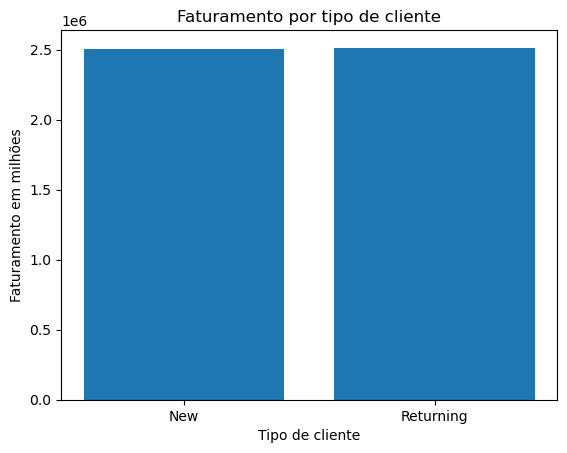

In [98]:
#Faturamento por tipo de cliente, se é novo ou um recorrente
faturamento_tipo_cliente = df.groupby('Customer_Type')['Sales_Amount'].sum()

plt.bar(faturamento_tipo_cliente.index, faturamento_tipo_cliente.values)
plt.xlabel("Tipo de cliente")
plt.ylabel("Faturamento em milhões")
plt.title("Faturamento por tipo de cliente")
plt.show()

Ambos os tipos de clientes não tem uma diferença significativa com relação ao faturamento

# Forma de pagamento mais utilizado

Text(0.5, 1.0, 'Quantidade de vendas por metodo de pagamento')

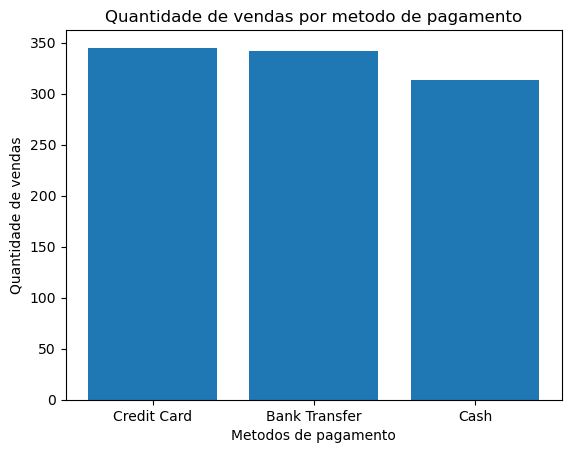

In [99]:
#Forma de pagamento mais usada
metodo_pagamento = df["Payment_Method"].value_counts()

plt.bar(metodo_pagamento.index, metodo_pagamento.values)
plt.xlabel("Metodos de pagamento")
plt.ylabel("Quantidade de vendas")
plt.title("Quantidade de vendas por metodo de pagamento")

Podemos identificar que o Credit Card e Bank Transfer estao equilibrados no entanto em relação a eles o Cash esta baixo

Uma boa opção para melhorar esses numeros de Cash tendo em vista que não possuem taxas como os outros metodos descritos, podiamos realizar campanhas de descontos utilizando Cash

# Criando database para consulta em SQL

In [104]:
conn = sqlite3.connect('../database.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

conn.close()

# Análises com SQL

Faturamento por categoria

In [111]:
conn = sqlite3.connect('../database.db')

query = '''
SELECT Product_Category, SUM(Sales_Amount) as faturamento
FROM sales
GROUP BY Product_Category
ORDER BY faturamento DESC'''

data = pd.read_sql(query, conn)
data

,Product_Category,faturamento
0,Clothing,1313474.36
1,Furniture,1260517.69
2,Electronics,1243499.64
3,Food,1201773.54


Categoria que mais fatura é Clothing

In [116]:
query = '''
SELECT Region, SUM(Sales_Amount) as faturamento
FROM sales
GROUP BY  Region
ORDER BY faturamento DESC
'''

data = pd.read_sql(query, conn)
data

,Region,faturamento
0,North,1369612.51
1,East,1259792.93
2,West,1235608.93
3,South,1154250.86


Região com mais faturamento é North, ja o com menos é South

Agora analise de quantidade de cada metodos de pagamento utilizado

In [136]:
query = ''' 
SELECT Payment_method, COUNT(*) as quantidade
FROM sales
GROUP BY Payment_method
ORDER BY quantidade DESC
'''

data

,Payment_Method,quantidade
0,Credit Card,345
1,Bank Transfer,342
2,Cash,313


Podemos ver aspectos parecidos com a questao de faturamento, tanto em quantidade e faturamento, Cash em ambos esta bem abaixo que o  restante